In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("100kb_ab.txt", sep="\t")
df.columns = ["chrom", "start","end", "E1_WT", "E1_PI"]
df

,chrom,start,end,E1_WT,E1_PI
0,chr1,0,100000,1.390066,1.496458
1,chr1,100000,200000,1.397436,1.615904
2,chr1,200000,300000,1.178881,1.422519
3,chr1,300000,400000,1.235158,1.559180
4,chr1,400000,500000,1.191308,1.354064
...,...,...,...,...,...
23923,chrX,125500000,125600000,0.344995,0.452348
23924,chrX,125600000,125700000,0.119520,0.154523
23925,chrX,125700000,125800000,0.064417,-0.026923
23926,chrX,125800000,125900000,0.151223,0.451196


In [3]:
df['type'] = None

In [12]:
df.loc[(df["E1_WT"]>0)&(df["E1_PI"]>0)&((df["E1_PI"]/(df["E1_WT"]+0.0000001))<2)&((df["E1_PI"]/(df["E1_WT"]+0.0000001))>0.5), 'type'] = 'stableA'
df.loc[(df["E1_WT"]>0)&(df["E1_PI"]>0)&((df["E1_PI"]/(df["E1_WT"]+0.0000001))<0.5), 'type'] = 'weakerA'
df.loc[(df["E1_WT"]>0)&(df["E1_PI"]>0)&((df["E1_PI"]/(df["E1_WT"]+0.0000001))>2), 'type'] = 'strongerA'

df.loc[(df["E1_WT"]<0)&(df["E1_PI"]<0)&((df["E1_PI"]/(df["E1_WT"]+0.0000001))<2)&((df["E1_PI"]/(df["E1_WT"]+0.0000001))>0.5), 'type'] = 'stableB'
df.loc[(df["E1_WT"]<0)&(df["E1_PI"]<0)&((df["E1_PI"]/(df["E1_WT"]+0.0000001))<0.5), 'type'] = 'weakerB'
df.loc[(df["E1_WT"]<0)&(df["E1_PI"]<0)&((df["E1_PI"]/(df["E1_WT"]+0.0000001))>2), 'type'] = 'strongerB'

df.loc[(df["E1_WT"]>0)&(df["E1_PI"]<0), 'type'] = 'AB'
df.loc[(df["E1_WT"]<0)&(df["E1_PI"]>0), 'type'] = 'BA'
df

,chrom,start,end,E1_WT,E1_PI,type
0,chr1,0,100000,1.390066,1.496458,stableA
1,chr1,100000,200000,1.397436,1.615904,stableA
2,chr1,200000,300000,1.178881,1.422519,stableA
3,chr1,300000,400000,1.235158,1.559180,stableA
4,chr1,400000,500000,1.191308,1.354064,stableA
...,...,...,...,...,...,...
23923,chrX,125500000,125600000,0.344995,0.452348,stableA
23924,chrX,125600000,125700000,0.119520,0.154523,stableA
23925,chrX,125700000,125800000,0.064417,-0.026923,AB
23926,chrX,125800000,125900000,0.151223,0.451196,strongerA


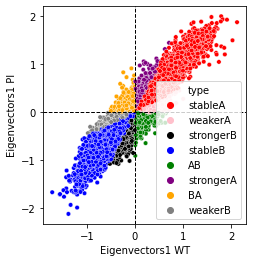

In [19]:
import seaborn as sns

sns.scatterplot(x=df["E1_WT"], y=df["E1_PI"], data=df, hue=df["type"], s=20, edgecolors=None, palette=['red','pink','black','blue','green','purple','orange','grey'])
plt.gca().set_aspect(1.0)
plt.axhline(y=0, linestyle='--', color="black", linewidth=1)
plt.axvline(x=0, linestyle='--', color="black", linewidth=1)
plt.xlabel("Eigenvectors1 WT")
plt.ylabel("Eigenvectors1 PI")
plt.savefig("ABscatterdetail.pdf")